In [43]:
# import robot_loader from scripts
import pinocchio as pin
import crocoddyl
import os
import numpy as np
from scripts.robot_loader import *
import meshcat.geometry as mg

# load model on Meshcat
model, collision_model, visual_model, robot_visualizer, viz = launch_visualization()

print(f"--- Pinocchio model datas ---")
print(f"Robot name: {model.name}")
print(f"Configuration dimension (nq): {model.nq}")
print(f"Velocity dimension (nv): {model.nv}")

data = model.createData()
robot_visualizer.data = data

# Display some frames
frames_to_display = ["pelvis", "left_ground", "right_ground"]
frame_ids = [model.getFrameId(frame_name) for frame_name in frames_to_display]
robot_visualizer.displayFrames(True, frame_ids)

# Display the robot on in initial position, with his feets close to the ground
q0 = pin.neutral(model)
q0[2] = 1.03
robot_visualizer.display(q0)
pin.forwardKinematics(model, data, q0)
pin.updateFramePlacements(model, data)

# get ids for contacts
left_foot_id = model.getFrameId("left_ground")
right_foot_id = model.getFrameId("right_ground")
contact_frame_ids = [left_foot_id, right_foot_id]

--- Searching for robot paths ---
Detected project root directory: /home/cpene/Documents/robot_playground
Asset paths verified.
Detected urdf file: /home/cpene/Documents/robot_playground/robot_models/h1_2/h1_2_handless.urdf
Detected mesh directory: /home/cpene/Documents/robot_playground/robot_models/h1_2
Launching MeshCat...
You can open the visualizer by visiting the following URL:
http://127.0.0.1:7007/static/
Adding a grid to represent the ground.
Loading robot model into Pinocchio...
Pinocchio model loaded successfully.
Frame 'left_ground' added successfully.
Frame 'right_ground' added successfully.

Environment is ready !
--- Pinocchio model datas ---
Robot name: h1_2
Configuration dimension (nq): 34
Velocity dimension (nv): 33


In [44]:
# Initial guess
# I want to provide a "valide" command for the first input
v0 = np.zeros(model.nv)
a0 = np.zeros(model.nv)
full_gravity_torques = pin.rnea(model, data, q0, v0, a0)
u0 = full_gravity_torques[6:] # this represent the command to counter gravity.

x0 = np.concatenate([q0, v0]) # This represent initial configuration with v = 0

In [74]:
# define parameters 
TRAJECTORY_DURATION = 3.0
HORIZON_LENGTH = 50
OCP_DT = 0.02         # 50 Hz
PHYSICS_DT = 0.001    # 1000 Hz
RATIO_PHYSICS_PER_OCP = int(OCP_DT / PHYSICS_DT)
assert OCP_DT % PHYSICS_DT == 0, "OCP_DT has to be a multiple of PHYSICS_DT"
N_OCP_STEPS = int(TRAJECTORY_DURATION / OCP_DT)

In [75]:
# Define a trajectory for the CoM to follow
pin.forwardKinematics(model, data, q0, v0)
pin.updateFramePlacements(model, data)
pin.centerOfMass(model, data, q0, v0)

z_com_highest = data.com[0][2].copy()
print(f"Initial position of CoM (x, y, z): {np.round(data.com[0], 3)}")

z_com_lower = z_com_highest.copy()
z_com_lower -= 0.20
print(f"Final position of CoM (x, y, z):   {np.round(z_com_lower, 3)}")

mean_com = (z_com_highest + z_com_lower) / 2.0
amplitude = (z_com_highest - z_com_lower) / 2.0
z_com_trajectory = [mean_com + amplitude * np.cos(2* np.pi * t / N_OCP_STEPS) for t in range(N_OCP_STEPS)]

# finish trajectory with initial values from TRAJECTORY_STEP to (TRAJECTORY_STEP + HORIZON_LENGTH)
trajectory_extension = [z_com_highest] * HORIZON_LENGTH
z_com_trajectory.extend(trajectory_extension)

# format trajectory with x and y
reference_com_trajectory = [np.array([0.011, 0.001, z]) for z in z_com_trajectory]

Initial position of CoM (x, y, z): [0.011 0.001 0.94 ]
Final position of CoM (x, y, z):   0.74


In [77]:
# I want to chain OCP problem in order to solve a small part of a trajectory
from ocp_tools.ocp_builder import OCPBuilder
from ocp_tools.cost_manager import CostModelManager
from ocp_tools.contact_manager import ContactModelManager

x_current = x0.copy()

ocp_save = []
physics_log = [x_current.copy()]

# first guess, used for warm start. it will be updated with result from previous OCP.
xs_init = [x0 for _ in range(HORIZON_LENGTH + 1)]
us_init = [u0 for _ in range(HORIZON_LENGTH)]

# initialize OCP
ocp_build = OCPBuilder(initial_state=x_current,
                                 rmodel=model,
                                 dt=OCP_DT,
                                 horizon_length=HORIZON_LENGTH)

# Create contacts
running_contact_managers = []
for j in range (HORIZON_LENGTH):
    contact_manager = ContactModelManager(ocp_build.state, ocp_build.actuation, model, data)
    contact_manager.add_contact_6D("left_ground") \
                   .add_contact_6D("right_ground")
    running_contact_managers.append(contact_manager)

terminal_contact_manager = ContactModelManager(ocp_build.state, ocp_build.actuation, model, data) \
            .add_contact_6D("left_ground") \
            .add_contact_6D("right_ground")

# DEBUG contacts
#terminal_contact_manager.display_contacts()

# create initial costs - will have to be updated between each OCP
running_cost_managers = []
config_filepath = 'config/H1_squat/regulation_state_weights.yaml'
for j in range (HORIZON_LENGTH):
    cost_manager = CostModelManager(ocp_build.state, ocp_build.actuation)
    cost_manager.add_CoM_position_cost(np.array(reference_com_trajectory[j]), 1e2) \
                  .add_weighted_regulation_state_cost(x_ref=x0, config_filepath=config_filepath, weight=1e-2) \
                  .add_regulation_control_cost(1e-6) \
                  .add_contact_friction_cone_cost(contact_frame_ids, 0.7, 1e-6)

    running_cost_managers.append(cost_manager)

terminal_cost_manager = CostModelManager(ocp_build.state, ocp_build.actuation)
terminal_cost_manager.add_regulation_state_cost(x_ref=x0, weight=1e-2)
                        #.add_CoM_position_cost(np.array(reference_com_trajectory[HORIZON_LENGTH]), 1e1) \
                        #.add_contact_friction_cone_cost(contact_frame_ids, 0.7, 1e-6)
                     

# DEBUG costs
#terminal_cost_manager.display_costs()

# Finalize OCP
problem = ocp_build.build(running_cost_managers, terminal_cost_manager, running_contact_managers, terminal_contact_manager)
solver = crocoddyl.SolverFDDP(problem)
MAX_ITER = 500

# these costs with reference will have to change along the movement
running_com_costs = [m.differential.costs.costs['com_position'].cost for m in problem.runningModels]
#running_reg_costs = [m.differential.costs.costs['regulation_weighted_state'].cost for m in problem.runningModels]
#terminal_com_cost = problem.terminalModel.differential.costs.costs['com_position'].cost
#terminal_reg_cost = problem.terminalModel.differential.costs.costs['regulation_state'].cost


# create phycics simulator with different dt.
simulator_diff_model = problem.runningModels[0].differential
simulator_action_model = crocoddyl.IntegratedActionModelRK(simulator_diff_model, crocoddyl.RKType(4), PHYSICS_DT)
simulator_data = simulator_action_model.createData()


for i in range(N_OCP_STEPS):

    problem.x0 = x_current.copy() 
    #ocp_build.set_initial_state(x_current.copy())

    # update reference for CoM (trajectory to follow)
    current_com_ref = []
    for j in range(HORIZON_LENGTH):
        ref = reference_com_trajectory[i + j]
        running_com_costs[j].residual.reference = ref
        current_com_ref.append(ref.copy())
    terminal_com_cost.residual.reference = reference_com_trajectory[i + HORIZON_LENGTH]

    # update reference for regulation 
    #for cost in running_reg_costs:
    #    cost.residual.reference = x_current
    #terminal_reg_cost.residual.reference = x_current

    converged = solver.solve(xs_init, us_init, MAX_ITER, False)
    if converged:
        print(f"SUCCESS: FDDP {i} converged in {solver.iter} iterations.")
    else:
        print(f"FAILURE: FDDP {i} did not converge.")
        break

    # get result from solver to be used as next input
    u_optimal = solver.us[0].copy()

    # save ocp informations
    ocp_snapshot = {
        "iteration": i,
        "converged": converged,
        "solver_iterations": solver.iter,
        "cost": solver.cost,
        "initial_state": x_current.copy(),
        "xs": [x.copy() for x in solver.xs],
        "us": [u.copy() for u in solver.us],
        "com_reference": current_com_ref,
    }
    ocp_save.append(ocp_snapshot)

    for _ in range(RATIO_PHYSICS_PER_OCP):
        simulator_action_model.calc(simulator_data, x_current, u_optimal)
        x_current = simulator_data.xnext.copy()
        physics_log.append(x_current.copy())
    
    # warm start
    xs_init = list(solver.xs)[1:] + [list(solver.xs)[-1]]
    us_init = list(solver.us)[1:] + [list(solver.us)[-1]]

SUCCESS: FDDP 0 converged in 39 iterations.
SUCCESS: FDDP 1 converged in 30 iterations.
SUCCESS: FDDP 2 converged in 29 iterations.
SUCCESS: FDDP 3 converged in 28 iterations.
SUCCESS: FDDP 4 converged in 24 iterations.
SUCCESS: FDDP 5 converged in 31 iterations.
SUCCESS: FDDP 6 converged in 27 iterations.
SUCCESS: FDDP 7 converged in 36 iterations.
SUCCESS: FDDP 8 converged in 30 iterations.
SUCCESS: FDDP 9 converged in 30 iterations.
SUCCESS: FDDP 10 converged in 29 iterations.
SUCCESS: FDDP 11 converged in 30 iterations.
SUCCESS: FDDP 12 converged in 30 iterations.
SUCCESS: FDDP 13 converged in 30 iterations.
SUCCESS: FDDP 14 converged in 31 iterations.
SUCCESS: FDDP 15 converged in 30 iterations.
SUCCESS: FDDP 16 converged in 30 iterations.
SUCCESS: FDDP 17 converged in 42 iterations.
SUCCESS: FDDP 18 converged in 41 iterations.
SUCCESS: FDDP 19 converged in 36 iterations.
SUCCESS: FDDP 20 converged in 42 iterations.
SUCCESS: FDDP 21 converged in 31 iterations.
SUCCESS: FDDP 22 con

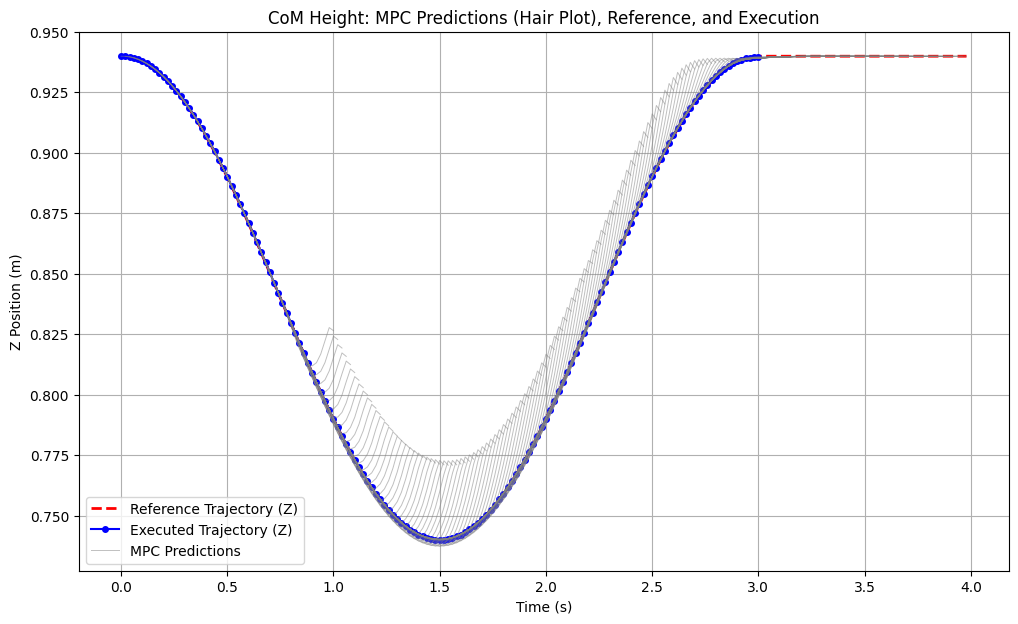

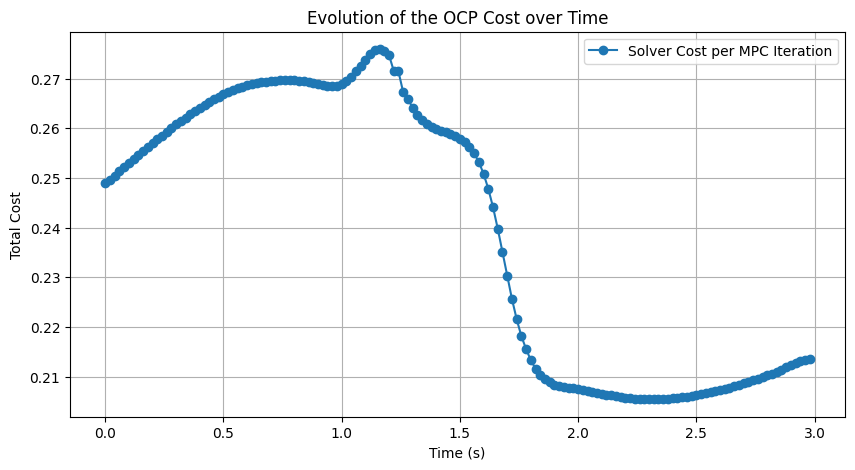

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import pinocchio as pin

# --- 1. EXTRACTION DES DONNÉES À PARTIR DE 'ocp_save' ---

# On s'assure qu'on a bien des données à tracer
if not ocp_save:
    print("La liste 'ocp_save' est vide. Aucune donnée à tracer.")
else:
    # On crée un seul objet data temporaire pour être efficace
    data_temp = model.createData()

    # Extraire la trajectoire du CoM réellement exécutée
    # C'est l'état xs[1] de chaque prédiction qui est devenu le nouvel état courant
    com_executed_trajectory = []
    # On commence par le CoM de l'état initial x0
    pin.centerOfMass(model, data_temp, x0[:model.nq])
    com_executed_trajectory.append(data_temp.com[0].copy())
    
    # Puis on ajoute le CoM de chaque pas de temps réalisé
    for snapshot in ocp_save:
        # L'état x_next était le deuxième état (index 1) de la prédiction
        x_executed = snapshot['xs'][1]
        q_executed = x_executed[:model.nq]
        pin.centerOfMass(model, data_temp, q_executed)
        com_executed_trajectory.append(data_temp.com[0].copy())

    # --- 2. PRÉPARATION DES DONNÉES POUR LE PLOT ---

    # Trajectoire de référence (inchangé)
    z_reference = [com[2] for com in reference_com_trajectory]
    time_axis_reference = np.arange(len(z_reference)) * OCP_DT

    # Trajectoire exécutée (maintenant extraite de ocp_save)
    z_executed = [com[2] for com in com_executed_trajectory]
    # L'axe de temps va de 0 à N (N+1 points)
    time_axis_executed = np.arange(len(z_executed)) * OCP_DT


    # --- 3. TRAÇAGE DU GRAPHIQUE ---
    
    plt.figure(figsize=(12, 7))

    # Tracer la trajectoire de référence
    plt.plot(time_axis_reference, z_reference, 'r--', linewidth=2, label="Reference Trajectory (Z)")

    # Tracer la trajectoire exécutée
    if z_executed:
        plt.plot(time_axis_executed, z_executed, 'b-o', markersize=4, label="Executed Trajectory (Z)")

    # Tracer le graphique "cheveux" à partir de ocp_save
    # C'est la partie principale de la correction
    for i, snapshot in enumerate(ocp_save):
        # L'axe de temps pour cette prédiction commence à t=i
        time_axis_prediction = (i + np.arange(len(snapshot['xs']))) * OCP_DT
        
        # Extraire la coordonnée Z de cette prédiction
        z_prediction = []
        for x_pred in snapshot['xs']:
            q_pred = x_pred[:model.nq]
            pin.centerOfMass(model, data_temp, q_pred)
            z_prediction.append(data_temp.com[0][2]) # On prend directement la coordonnée Z
        
        # Tracer cette prédiction avec une couleur légère et semi-transparente
        label = "MPC Predictions" if i == 0 else ""
        plt.plot(time_axis_prediction, z_prediction, color='gray', linestyle='-', linewidth=0.7, alpha=0.5, label=label)

    # Mettre en forme le graphique
    plt.title("CoM Height: MPC Predictions (Hair Plot), Reference, and Execution")
    plt.xlabel("Time (s)")
    plt.ylabel("Z Position (m)")
    plt.grid(True)
    
    # Ré-ordonner les éléments de la légende pour une meilleure lisibilité
    handles, labels = plt.gca().get_legend_handles_labels()
    # On crée une liste d'ordre en s'assurant que les labels existent bien
    order = []
    if "Reference Trajectory (Z)" in labels: order.append(labels.index("Reference Trajectory (Z)"))
    if "Executed Trajectory (Z)" in labels: order.append(labels.index("Executed Trajectory (Z)"))
    if "MPC Predictions" in labels: order.append(labels.index("MPC Predictions"))
    
    plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])

    plt.show()


# Extraire le coût de chaque itération
costs_over_time = [snapshot['cost'] for snapshot in ocp_save]

# Créer l'axe du temps
time_axis = np.arange(len(costs_over_time)) * OCP_DT

plt.figure(figsize=(10, 5))
plt.plot(time_axis, costs_over_time, '-o', label="Solver Cost per MPC Iteration")
plt.xlabel("Time (s)")
plt.ylabel("Total Cost")
plt.title("Evolution of the OCP Cost over Time")
plt.grid(True)
plt.legend()
plt.show()



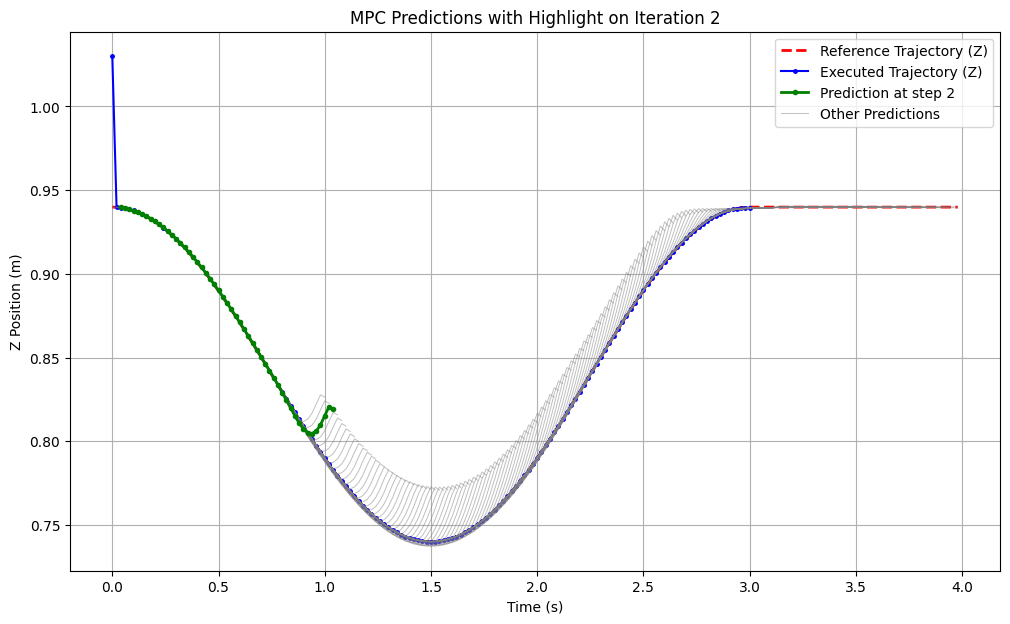

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import pinocchio as pin

# ==============================================================================
#  PARAMÈTRE À MODIFIER : Choisissez l'itération MPC à mettre en évidence
# ==============================================================================
ITERATION_TO_HIGHLIGHT = 2  # Mettez la valeur de votre choix (ex: 0, 25, 100...)
# ==============================================================================


# On s'assure qu'on a bien des données à tracer
if 'ocp_save' not in locals() or not ocp_save:
    print("La liste 'ocp_save' est vide ou n'existe pas. Exécutez d'abord la simulation MPC.")

elif ITERATION_TO_HIGHLIGHT >= len(ocp_save):
    print(f"Erreur : L'itération {ITERATION_TO_HIGHLIGHT} est hors des limites.")
    print(f"Veuillez choisir une valeur entre 0 et {len(ocp_save) - 1}.")

else:
    # --- 1. PRÉPARATION DES DONNÉES (identique à votre code) ---
    data_temp = model.createData()

    # Trajectoire de référence globale
    z_reference = [com[2] for com in reference_com_trajectory]
    time_axis_reference = np.arange(len(z_reference)) * OCP_DT

    # Trajectoire exécutée globale
    com_executed_trajectory = [x0[:3]] # CoM initial
    for snapshot in ocp_save:
        x_executed = snapshot['xs'][1]
        pin.centerOfMass(model, data_temp, x_executed[:model.nq])
        com_executed_trajectory.append(data_temp.com[0].copy())
    z_executed = [com[2] for com in com_executed_trajectory]
    time_axis_executed = np.arange(len(z_executed)) * OCP_DT

    # --- 2. TRAÇAGE DU GRAPHIQUE ---
    plt.figure(figsize=(12, 7))

    # Tracer la référence et l'exécuté comme avant
    plt.plot(time_axis_reference, z_reference, 'r--', linewidth=2, label="Reference Trajectory (Z)")
    plt.plot(time_axis_executed, z_executed, 'b-', marker='.', markersize=5, label="Executed Trajectory (Z)")

    # --- 3. MODIFICATION DU "HAIR PLOT" ---
    # On boucle sur toutes les prédictions sauvegardées
    for i, snapshot in enumerate(ocp_save):
        # Calcul de la trajectoire Z de cette prédiction (inchangé)
        time_axis_prediction = (i + np.arange(len(snapshot['xs']))) * OCP_DT
        z_prediction = []
        for x_pred in snapshot['xs']:
            q_pred = x_pred[:model.nq]
            pin.centerOfMass(model, data_temp, q_pred)
            z_prediction.append(data_temp.com[0][2])
        
        # Condition pour tracer différemment la courbe choisie
        if i == ITERATION_TO_HIGHLIGHT:
            # Tracer la prédiction choisie en vert, bien visible et par-dessus le reste
            plt.plot(time_axis_prediction, z_prediction, 
                     color='green', linestyle='-', linewidth=2, marker='o', markersize=3,
                     label=f"Prediction at step {i}", zorder=10)
        else:
            # Tracer toutes les autres prédictions en gris léger
            label = "Other Predictions" if i == 0 else ""
            plt.plot(time_axis_prediction, z_prediction, 
                     color='gray', linestyle='-', linewidth=0.7, alpha=0.5, label=label)

    # Mettre en forme le graphique
    plt.title(f"MPC Predictions with Highlight on Iteration {ITERATION_TO_HIGHLIGHT}")
    plt.xlabel("Time (s)")
    plt.ylabel("Z Position (m)")
    plt.grid(True)
    
    # Ré-ordonner la légende pour la clarté
    handles, labels = plt.gca().get_legend_handles_labels()
    order = []
    legend_order = ["Reference Trajectory (Z)", "Executed Trajectory (Z)", f"Prediction at step {ITERATION_TO_HIGHLIGHT}", "Other Predictions"]
    for lbl in legend_order:
        if lbl in labels:
            order.append(labels.index(lbl))
    plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order])

    plt.show()


Préparation du graphique pour la coordonnée Z du CoM...


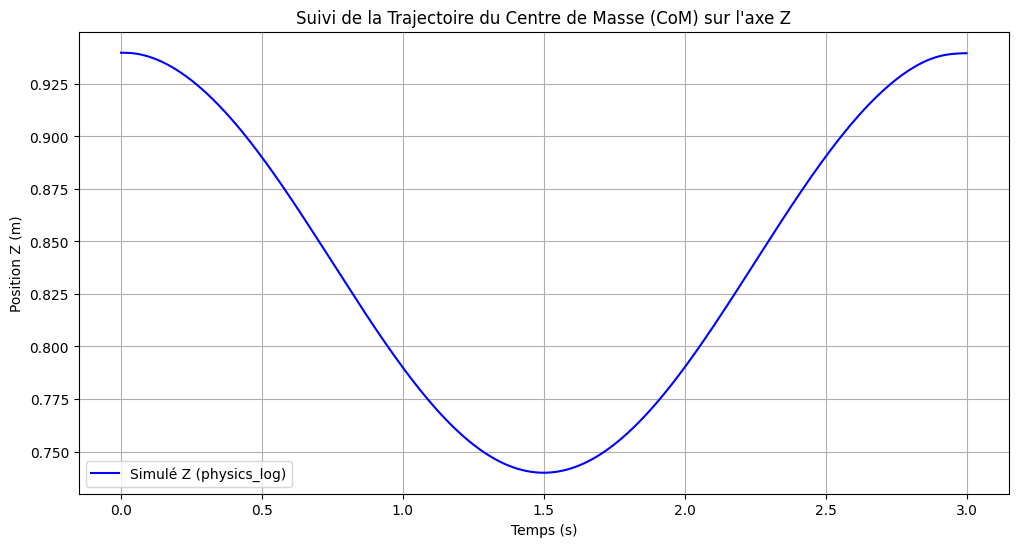

In [80]:
import matplotlib.pyplot as plt
import numpy as np
import pinocchio as pin

# ==============================================================================
# Code de Visualisation - CoM en Z (Référence vs. Simulation)
# ==============================================================================

print("Préparation du graphique pour la coordonnée Z du CoM...")

# --- 1. Extraire la trajectoire Z simulée depuis physics_log ---
# On recalcule la position du CoM pour chaque état 'x' enregistré à haute fréquence
z_simulated_physics = []
for x_state in physics_log:
    q = x_state[:model.nq]
    pin.centerOfMass(model, data, q) # Pas besoin de la vitesse pour la position du CoM
    z_simulated_physics.append(data.com[0][2]) # On ne garde que la coordonnée Z

# Créer l'axe de temps correspondant pour la simulation physique
time_physics = np.arange(len(z_simulated_physics)) * PHYSICS_DT



# --- 3. Créer le graphique ---
plt.figure(figsize=(12, 6))
plt.plot(time_physics, z_simulated_physics, 'b-', linewidth=1.5, label='Simulé Z (physics_log)')

# --- Améliorer la lisibilité ---
plt.title('Suivi de la Trajectoire du Centre de Masse (CoM) sur l\'axe Z')
plt.xlabel('Temps (s)')
plt.ylabel('Position Z (m)')
plt.legend()
plt.grid(True)
plt.show()


In [84]:
# Launch the simulation
import time

OCP_DT = 0.033

q_executed_trajectory = [q0.copy()]
for snapshot in ocp_save:
    x_executed = snapshot['xs'][1]
    q_executed = x_executed[:model.nq]
    q_executed_trajectory.append(q_executed)
    
print("Starting animation...")

for q in q_executed_trajectory:
        robot_visualizer.display(q)
        time.sleep(OCP_DT)

print("\nAnimation finished.")


Starting animation...

Animation finished.
